In [196]:
import pandas as pd

#items = pd.read_csv('item.csv')
items = pd.read_csv('https://merkle-de-interview-case-study.s3.eu-central-1.amazonaws.com/de/item.csv')

Generic checs for getting to know the structure of file - present columns and infer from naming what whole dataset represents

In [206]:
items.head(10)

,adjective,category,created_at,id,modifier,name,price
0,fuzzy,contraption,2014-01-15 21:36:09,2512.0,carrying_case,fuzzy contraption carrying_case,150.00
1,NaN,instrument,2013-05-14 05:20:50,482.0,refill,instrument refill,35.20
2,industrial-strength,module,2014-02-04 19:28:32,2446.0,NaN,industrial-strength module,300.00
3,digital,tool,2013-02-25 12:23:18,1312.0,carrying_case,digital tool carrying_case,16.50
4,miniature,device,2013-08-05 17:20:45,3556.0,cleaner,miniature device cleaner,16.50
5,rechargable,contraption,2013-09-12 06:27:01,131.0,cleaner,rechargable contraption cleaner,195.00
6,NaN,instrument,2013-10-07 09:38:14,1178.0,how-to-manual,instrument how-to-manual,0.00
7,prize-winning,mechanism,2013-09-09 09:32:18,110.0,storage_unit,prize-winning mechanism storage_unit,41.25
8,NaN,mechanism,2013-10-25 22:53:25,47.0,NaN,mechanism,15.00
9,organic,tool,2013-05-10 10:19:33,1696.0,NaN,organic tool,37.50


In [6]:

print(f"Columns in items: {items.columns}")
print(f"Total rows: {items.count()}")

for col in ("adjective", "category"):
    print(f"Unique values for column {col}: {items[col].unique()}")
    
price = items['price']
print(f"Price range: {price.min()} to {price.max()}")

Columns in items: Index(['adjective', 'category', 'created_at', 'id', 'modifier', 'name',
       'price'],
      dtype='str')
Total rows: adjective     1926
category      2198
created_at    2198
id            2198
modifier      1432
name          2198
price         2198
dtype: int64
Unique values for column adjective: <StringArray>
[              'fuzzy',                   nan, 'industrial-strength',
             'digital',           'miniature',         'rechargable',
       'prize-winning',             'organic',          'reflective',
         'aerodynamic',              'analog',      'extra-strength',
               'matte',              'glossy']
Length: 14, dtype: str
Unique values for column category: <StringArray>
['contraption',  'instrument',      'module',        'tool',      'device',
   'mechanism',      'widget',   'apparatus',      'gadget',      'dongle']
Length: 10, dtype: str
Price range: 0.0 to 2250.0


price    Axes(0.125,0.11;0.775x0.77)
dtype: object

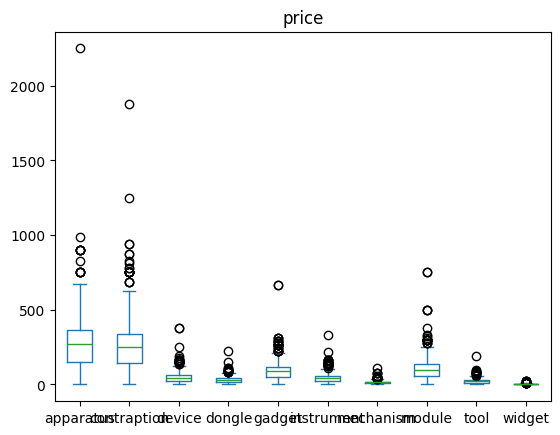

In [11]:
items.plot.box(column='price', by="category")

price    Axes(0.125,0.11;0.775x0.77)
dtype: object

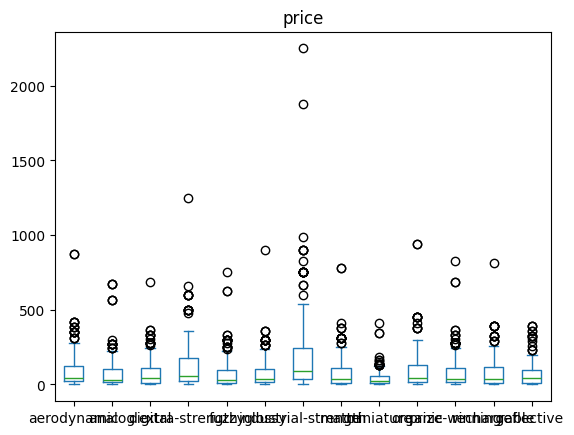

In [13]:
items.plot.box(column='price', by="adjective")

Check the missing values of columns to get the idea of required fields

In [ ]:
for col in items:
    print(f"Column {col} has missing values: {items[col].isna().sum()}")

Column adjective has missing values: 272
Column category has missing values: 0
Column created_at has missing values: 0
Column id has missing values: 0
Column modifier has missing values: 766
Column name has missing values: 0
Column price has missing values: 0


Determine if rows have a repeated column that does not have any missing value to get the idea of the domain.

In [ ]:
# Total number of records
print(f"Total number of rows in items: {len(items)}")
print(f"Total number of values in `name` column: {items['name'].count()}")

print(f"Total number of unique values {items['name'].nunique()}")


Total number of rows in items: 2198
Total number of values in `name` column: 2198
Total number of unique values 1011


The whole dataset probably represents a pricesheet/pricelist or is a sales data (individually sold items). Determine if there is a repeated tuple (e.g. category and name). If not then `id` refers to unique tuple which would make this a price sheet. Otherwise, assuming it is not an error this would be sales data.

In [52]:
items[['id', 'adjective', 'category', 'name', 'price']].sort_values(by=["category", "adjective", "name"])

,id,adjective,category,name,price
159,2035.0,aerodynamic,apparatus,aerodynamic apparatus,420.0
706,921.0,aerodynamic,apparatus,aerodynamic apparatus,420.0
801,1510.0,aerodynamic,apparatus,aerodynamic apparatus,420.0
1483,2867.0,aerodynamic,apparatus,aerodynamic apparatus,420.0
966,3218.0,aerodynamic,apparatus,aerodynamic apparatus charger,84.0
...,...,...,...,...,...
965,3450.0,NaN,widget,widget refill,2.4
1029,129.0,NaN,widget,widget refill,2.4
1569,2703.0,NaN,widget,widget warmer,3.3
2036,1390.0,NaN,widget,widget warmer,3.3


In [113]:
grouped = items.groupby(['adjective', 'category', 'name', 'price']).transform('size')
items[grouped > 1]

,adjective,category,created_at,id,modifier,name,price
0,fuzzy,contraption,2014-01-15 21:36:09,2512.0,carrying_case,fuzzy contraption carrying_case,150.00
2,industrial-strength,module,2014-02-04 19:28:32,2446.0,NaN,industrial-strength module,300.00
4,miniature,device,2013-08-05 17:20:45,3556.0,cleaner,miniature device cleaner,16.50
5,rechargable,contraption,2013-09-12 06:27:01,131.0,cleaner,rechargable contraption cleaner,195.00
7,prize-winning,mechanism,2013-09-09 09:32:18,110.0,storage_unit,prize-winning mechanism storage_unit,41.25
...,...,...,...,...,...,...,...
2190,fuzzy,module,2013-10-21 08:25:44,1395.0,storage_unit,fuzzy module storage_unit,250.00
2191,digital,gadget,2013-11-01 15:51:34,2926.0,NaN,digital gadget,97.90
2192,analog,device,2013-05-15 14:16:19,450.0,wrapper,analog device wrapper,18.00
2195,industrial-strength,dongle,2013-12-18 21:37:01,1393.0,refill,industrial-strength dongle refill,72.00


In [98]:
items[
    items['adjective'].eq('prize-winning') & items['category'].eq('gadget') & items['name'].eq('prize-winning gadget')
]

,adjective,category,created_at,id,modifier,name,price
246,prize-winning,gadget,2013-12-14 01:22:45,3084.0,NaN,prize-winning gadget,97.9
674,prize-winning,gadget,2014-02-25 23:19:47,3188.0,NaN,prize-winning gadget,97.9
676,prize-winning,gadget,2013-08-08 08:49:44,2310.0,NaN,prize-winning gadget,97.9
752,prize-winning,gadget,2013-10-21 21:16:35,2808.0,NaN,prize-winning gadget,97.9
873,prize-winning,gadget,2013-05-18 00:02:15,999.0,NaN,prize-winning gadget,97.9
1014,prize-winning,gadget,2013-04-12 14:48:39,1878.0,NaN,prize-winning gadget,97.9
1297,prize-winning,gadget,2013-12-01 05:09:59,1258.0,NaN,prize-winning gadget,97.9
1362,prize-winning,gadget,2013-09-24 19:14:41,3871.0,NaN,prize-winning gadget,97.9
1456,prize-winning,gadget,2013-11-15 17:41:18,1099.0,NaN,prize-winning gadget,97.9
1505,prize-winning,gadget,2013-04-25 16:30:19,3660.0,NaN,prize-winning gadget,97.9


Seems that items represent sales data - above example shows a repeated tuple of adjective,category, name and price that is repeated under different ids and happened at different time (created at).

#### Checks for event data

In [198]:
import pandas as pd

#events = pd.read_csv('event.csv')
events = pd.read_csv('https://merkle-de-interview-case-study.s3.eu-central-1.amazonaws.com/de/event.csv')


In [199]:

print(f"Columns in items: {events.columns}")
print(f"Total rows: {events}")
    

Columns in items: Index(['event_id', 'event_time', 'user_id', 'event.payload'], dtype='str')
Total rows:                                 event_id           event_time   user_id  \
0       b9de71c5c3cc4cd7a97e50b832106e5a  2017-06-26 11:23:39  178481.0   
1       23267713c9ea44419331731f50b6a8db  2017-06-27 10:46:39  178481.0   
2       1b7822fa7b854e01970218ae8f721fe0  2017-06-27 11:15:39  178481.0   
3       2a7a188a626841ac94befcc419f06af4  2016-10-05 20:43:10  154133.0   
4       631d657264cc4616a4528f759509b25d  2016-10-04 03:29:10  154133.0   
...                                  ...                  ...       ...   
853635  542e24088b464ca7b9a988986dfadb3e  2016-10-22 15:23:09  204159.0   
853636  3248a35b0c114408bd3d3a876574429b  2016-10-22 15:23:09  174668.0   
853637  7aaa43025ac64aa9b031d88907a4715e  2016-10-18 15:23:09  184075.0   
853638  a6c640ffda944ea2bd283e59262d0aa8  2016-10-12 15:23:09  218373.0   
853639  39b0fca5279649e1ba289300fcaa6aa0  2016-12-02 15:23:09  167256.

In [135]:
import json

event_payload = pd.json_normalize(events['event.payload'].apply(json.loads))

processed_events = events.join(event_payload)


In [137]:
processed_events

,event_id,event_time,user_id,event.payload,event_name,platform,parameter_name,parameter_value
0,b9de71c5c3cc4cd7a97e50b832106e5a,2017-06-26 11:23:39,178481.0,"{""event_name"":""view_item"",""platform"":""android""...",view_item,android,item_id,3526
1,23267713c9ea44419331731f50b6a8db,2017-06-27 10:46:39,178481.0,"{""event_name"":""view_item"",""platform"":""android""...",view_item,android,item_id,1514
2,1b7822fa7b854e01970218ae8f721fe0,2017-06-27 11:15:39,178481.0,"{""event_name"":""view_item"",""platform"":""android""...",view_item,android,item_id,3712
3,2a7a188a626841ac94befcc419f06af4,2016-10-05 20:43:10,154133.0,"{""event_name"":""view_item"",""platform"":""android""...",view_item,android,item_id,3586
4,631d657264cc4616a4528f759509b25d,2016-10-04 03:29:10,154133.0,"{""event_name"":""view_item"",""platform"":""android""...",view_item,android,item_id,1061
...,...,...,...,...,...,...,...,...
853635,542e24088b464ca7b9a988986dfadb3e,2016-10-22 15:23:09,204159.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,7
853636,3248a35b0c114408bd3d3a876574429b,2016-10-22 15:23:09,174668.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,7
853637,7aaa43025ac64aa9b031d88907a4715e,2016-10-18 15:23:09,184075.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,7
853638,a6c640ffda944ea2bd283e59262d0aa8,2016-10-12 15:23:09,218373.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,7


In [145]:

print(f"Columns in items: {processed_events.columns}")
print(f"Total rows: {processed_events.count()}")


Columns in items: Index(['event_id', 'event_time', 'user_id', 'event.payload', 'event_name',
       'platform', 'parameter_name', 'parameter_value'],
      dtype='str')
Total rows: event_id           853640
event_time         853640
user_id            853640
event.payload      853640
event_name         853640
platform           853640
parameter_name     853640
parameter_value    853640
dtype: int64


Check for unique users, assuming this is clickstream data

In [150]:
print(f"Unique user ids: {processed_events['user_id'].nunique()}")

Unique user ids: 109624


In [ ]:
for col in ('event_name', 'platform', 'parameter_name'):
    print(f"Unique {col} values: {processed_events[col].unique()}")
    
print(f"Event id size: {processed_events['event_id'].size}")
print(f"Events size: {processed_events.size}")


Unique event_name values: <StringArray>
['view_item', 'view_user_profile', 'test_assignment']
Length: 3, dtype: str
Unique platform values: <StringArray>
['android', 'web', 'mobile web', 'iOS', 'server']
Length: 5, dtype: str
Unique parameter_name values: <StringArray>
['item_id', 'referrer', 'viewed_user_id', 'test_assignment', 'test_id']
Length: 5, dtype: str
Event id size: 853640
Events size: 6829120
0


In [192]:
event_ids = processed_events.groupby('event_id').transform('size')
print(f"Number of repeated event_ids: {processed_events[event_ids > 1].size}")
processed_events.groupby('event_id').size()

Number of repeated event_ids: 6804416


event_id
00003d71b9cb41469c05af608a6d2145    2
00009c5122b04bc09d7677b5bae641c8    2
0000ac00b5b741a8928a911dc3448cb2    2
00012e89e2f54bf99180dde02c63e4ad    2
00012e8f6da84f33ab9ff53901f5a2f3    2
                                   ..
ffff62bdd4ed4594873f535871ec774a    2
ffff6b68428a40468e7c5e5b2d3ea3b7    2
ffff7a00a5034c1da51a6dc6d6e9e94b    2
ffff8b1919e14d19b3744a49f682dafd    2
ffff9476a6624306968e30835419729e    2
Length: 428364, dtype: int64

In [195]:
processed_events.sort_values(['event_id', 'event_time'])

,event_id,event_time,user_id,event.payload,event_name,platform,parameter_name,parameter_value
609730,00003d71b9cb41469c05af608a6d2145,2014-04-28 15:23:00,147689.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_assignment,1
678293,00003d71b9cb41469c05af608a6d2145,2014-04-28 15:23:00,147689.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,5
167202,00009c5122b04bc09d7677b5bae641c8,2017-10-06 14:33:32,198519.0,"{""event_name"":""view_item"",""platform"":""mobile w...",view_item,mobile web,item_id,3241
382526,00009c5122b04bc09d7677b5bae641c8,2017-10-06 14:33:32,198519.0,"{""event_name"":""view_item"",""platform"":""mobile w...",view_item,mobile web,referrer,shopping_cart
306884,0000ac00b5b741a8928a911dc3448cb2,2014-07-25 22:40:56,31861.0,"{""event_name"":""view_item"",""platform"":""web"",""pa...",view_item,web,item_id,2260
...,...,...,...,...,...,...,...,...
761535,ffff7a00a5034c1da51a6dc6d6e9e94b,2014-04-28 15:23:05,150292.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,6
812096,ffff8b1919e14d19b3744a49f682dafd,2016-11-16 15:23:09,293137.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_assignment,0
850743,ffff8b1919e14d19b3744a49f682dafd,2016-11-16 15:23:09,293137.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_id,7
790813,ffff9476a6624306968e30835419729e,2016-11-25 15:23:09,269984.0,"{""event_name"":""test_assignment"",""platform"":""se...",test_assignment,server,test_assignment,0


Final verdict is that this represents clickstream data.